In [ ]:
#Istallazione delle librerie.
import pandas as pd
from datetime import datetime
import numpy as np
try:

  %tensorflow_version 2.x
except Exception:
  pass
import tensorflow as tf
from math import sqrt
from numpy import concatenate
from matplotlib import pyplot
from pandas import read_csv
from pandas import DataFrame
from pandas import concat
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.utils import plot_model
!pip install pydot
!pip install graphviz

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [ ]:
from pandas import read_csv
from matplotlib import pyplot
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler
import pandas as pd # Import pandas

# convert series to supervised learning Questa funzione trasforma un dataset di serie storiche in un problema di apprendimento supervisionato.
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    n_vars = 1 if type(data) is list else data.shape[1]
    df = pd.DataFrame(data)
    cols, names = list(), list()
    # input sequence (t-n, ... t-1)
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
    # forecast sequence (t, t+1, ... t+n)
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
    # put it all together
    agg = pd.concat(cols, axis=1)
    agg.columns = names # Assign the generated names to the columns
    # drop rows with NaN values
    if dropnan:
        agg.dropna(inplace=True)
    return agg




In [ ]:
import pandas as pd
from sklearn.preprocessing import RobustScaler
import numpy as np

# 1. Caricamento dei  dati separati come segue .
dataset = pd.read_csv('../data/dataset_finale_4_anni.csv',
    header=0,
    index_col=0,
    decimal=',',
    thousands='.'
)

# 2. Prendi i valori.
values = dataset.values


print(values)
values.shape

[[4331.27 1811.57  170.28]
 [3983.88 1367.67  155.72]
 [3704.99 1334.19  147.09]
 ...
 [6062.15 2893.    150.  ]
 [5548.82 2382.94  141.  ]
 [4936.83 1882.24  134.32]]


(26304, 3)

In [ ]:
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

# Divisione tra train e test set

n_train_samples = 17520
train_values = values[:n_train_samples, :] # DUE ANNI
test_values = values[n_train_samples:, :] # un anno .

# SELZIONIAMO LO SCALER.
scaler =  RobustScaler()

# Applica .fit_transform() solo al set di training
scaled_train = scaler.fit_transform(train_values)


scaled_test = scaler.transform(test_values)


# 'scaled_train' e 'scaled_test' pronti per i passaggi successivi
print("Forma dei dati di training scalati:", scaled_train.shape)
print("Forma dei dati di test scalati:", scaled_test.shape)

Forma dei dati di training scalati: (17520, 3)
Forma dei dati di test scalati: (8784, 3)


PREPARAZIONE DELLE SEQUENZE



In [ ]:


#parametri della finestra temporale
N_IN = 72       # 3 giorni (72 ore) per predire l'ora successiva
N_FEATURES = 3    # Il numero di feature originali

#TRASFORMA IL SET DI TRAINING
reframed_train = series_to_supervised(scaled_train, n_in=N_IN, n_out=1)

# TRASFORMA IL SET DI TEST
reframed_test = series_to_supervised(scaled_test, n_in=N_IN, n_out=1)


#COLONNE DI OUTPUT NON NECESSARIE
# Dobbiamo eliminare le prime 3 colonne di output (var1(t), var2(t), var3(t)).
cols_to_drop = []
for i in range(N_FEATURES - 1):
    cols_to_drop.append(N_FEATURES * N_IN + i)

reframed_train.drop(reframed_train.columns[cols_to_drop], axis=1, inplace=True)
reframed_test.drop(reframed_test.columns[cols_to_drop], axis=1, inplace=True)


# Divisione finale IN INPUT (X) E OUTPUT (y)
train_values = reframed_train.values
test_values = reframed_test.values

train_X, train_y = train_values[:, :-1], train_values[:, -1]
test_X, test_y = test_values[:, :-1], test_values[:, -1]


# Verifica finale.
print("--- Set di Training ---")
print("Forma di train_X:", train_X.shape)
print("Forma di train_y:", train_y.shape)
print("\n--- Set di Test ---")
print("Forma di test_X:", test_X.shape)
print("Forma di test_y:", test_y.shape)
print("\nPrime 5 righe del set di training trasformato:")
print(reframed_train.head())

--- Set di Training ---
Forma di train_X: (17448, 216)
Forma di train_y: (17448,)

--- Set di Test ---
Forma di test_X: (8712, 216)
Forma di test_y: (8712,)

Prime 5 righe del set di training trasformato:
    var1(t-72)  var2(t-72)  var3(t-72)  var1(t-71)  var2(t-71)  var3(t-71)  \
72   -0.714675   -0.696229   -0.030920   -0.902530   -0.953528   -0.133939   
73   -0.902530   -0.953528   -0.133939   -1.053343   -0.972934   -0.195001   
74   -1.053343   -0.972934   -0.195001   -1.142450   -1.045846   -0.591867   
75   -1.142450   -1.045846   -0.591867   -1.179617   -1.072277   -0.499885   
76   -1.179617   -1.072277   -0.499885   -1.136356   -1.079076   -0.240921   

    var1(t-70)  var2(t-70)  var3(t-70)  var1(t-69)  ...  var1(t-3)  var2(t-3)  \
72   -1.053343   -0.972934   -0.195001   -1.142450  ...   0.471495  -0.256317   
73   -1.142450   -1.045846   -0.591867   -1.179617  ...   0.125581  -0.537804   
74   -1.179617   -1.072277   -0.499885   -1.136356  ...  -0.224064  -0.540128   
75

LSTM (100) PREVISIONE ORARIA TRASFORMABILE SELEZIONANDO BIDIRECTIONAL PRIMA DELLA LSTM


In [ ]:
from keras.models import Sequential
from keras.layers import LSTM, Dense
N_IN = 72 #per catturare variazioni nel weekwnd
N_FEATURES = 3

train_X = train_X.reshape((train_X.shape[0], N_IN, N_FEATURES))
test_X = test_X.reshape((test_X.shape[0],N_IN, N_FEATURES))

# Def modello
model = Sequential()
model.add(LSTM(100, input_shape=(N_IN, N_FEATURES)))
model.add(Dense(1))
model.compile(loss='mae', optimizer='adam')
print("Riepilogo del Modello Aggiornato:")
model.summary()
history = model.fit(
    train_X,
    train_y,
    epochs=30, #anche se dopo le 10 smette di imparare sensibilmente
    batch_size=64,
    validation_data=(test_X, test_y),
    verbose=2,
    shuffle=False
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Riepilogo del Modello Aggiornato:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        41,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,701 (162.89 KB)

 Trainable params: 41,701 (162.89 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
273/273 - 9s - 32ms/step - loss: 0.2095 - val_loss: 0.0925
Epoch 2/30
273/273 - 4s - 14ms/step - loss: 0.1386 - val_loss: 0.0717
Epoch 3/30
273/273 - 3s - 11ms/step - loss: 0.1099 - val_loss: 0.0634
Epoch 4/30
273/273 - 2s - 8ms/step - loss: 0.0966 - val_loss: 0.0563
Epoch 5/30
273/273 - 2s - 7ms/step - loss: 0.0886 - val_loss: 0.0528
Epoch 6/30
273/273 - 3s - 12ms/step - loss: 0.0841 - val_loss: 0.0511
Epoch 7/30
273/273 - 4s - 15ms/step - loss: 0.0824 - val_loss: 0.0495
Epoch 8/30
273/273 - 4s - 16ms/step - loss: 0.0811 - val_loss: 0.0488
Epoch 9/30
273/273 - 4s - 14ms/step - loss: 0.0807 - val_loss: 0.0480
Epoch 10/30
273/273 - 3s - 9ms/step - loss: 0.0808 - val_loss: 0.0480
Epoch 11/30
273/273 - 4s - 16ms/step - loss: 0.0796 - val_loss: 0.0477
Epoch 12/30
273/273 - 4s - 13ms/step - loss: 0.0796 - val_loss: 0.0475
Epoch 13/30
273/273 - 4s - 14ms/step - loss: 0.0799 - val_loss: 0.0457
Epoch 14/30
273/273 - 7s - 27ms/step - loss: 0.0784 - val_loss: 0.0476
Epoch 15/30
273/27

 ARCHITETURA IBRIDA CNN LSTM


In [ ]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Conv1D, MaxPooling1D

# I tuoi parametri
N_IN = 72
N_FEATURES = 3

# Reshape dei dati
train_X = train_X.reshape((train_X.shape[0], N_IN, N_FEATURES))
test_X = test_X.reshape((test_X.shape[0], N_IN, N_FEATURES))

# --- Inizio Definizione Modello CNN-LSTM ---
model = Sequential()

# 1. STRATO CONVOLUZIONALE (Conv1D)

model.add(Conv1D(filters= 256, kernel_size= 3, activation='relu', input_shape=(N_IN, N_FEATURES)))

# 2. STRATO DI MAXPOOLING
model.add(MaxPooling1D(pool_size=2))

# 3. STRATO LSTM
model.add(LSTM(100))

# 4. STRATO DI OUTPUT
model.add(Dense(1))

# --- Fine Definizione Modello ---

# Compilazione (invariata)
model.compile(loss='mae', optimizer='adam')

# Stampa un riepilogo del nuovo modello
print("Riepilogo del Modello CNN-LSTM:")
model.summary()

# Addestramento
history = model.fit(
    train_X,
    train_y,
    epochs=30,
    batch_size=64,
    validation_data=(test_X, test_y),
    verbose=2,
    shuffle=False
)

Riepilogo del Modello CNN-LSTM:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 70, 256)        │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 35, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100)            │       142,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145,461 (568.21 KB)

 Trainable params: 145,461 (568.21 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
273/273 - 4s - 15ms/step - loss: 0.2203 - val_loss: 0.0906
Epoch 2/30
273/273 - 2s - 9ms/step - loss: 0.1417 - val_loss: 0.0787
Epoch 3/30
273/273 - 2s - 8ms/step - loss: 0.1242 - val_loss: 0.0706
Epoch 4/30
273/273 - 2s - 7ms/step - loss: 0.1190 - val_loss: 0.0667
Epoch 5/30
273/273 - 2s - 7ms/step - loss: 0.1122 - val_loss: 0.0641
Epoch 6/30
273/273 - 2s - 8ms/step - loss: 0.1089 - val_loss: 0.0615
Epoch 7/30
273/273 - 2s - 7ms/step - loss: 0.1020 - val_loss: 0.0616
Epoch 8/30
273/273 - 2s - 9ms/step - loss: 0.0989 - val_loss: 0.0620
Epoch 9/30
273/273 - 2s - 7ms/step - loss: 0.0956 - val_loss: 0.0609
Epoch 10/30
273/273 - 2s - 7ms/step - loss: 0.0949 - val_loss: 0.0582
Epoch 11/30
273/273 - 2s - 7ms/step - loss: 0.0930 - val_loss: 0.0577
Epoch 12/30
273/273 - 2s - 7ms/step - loss: 0.0946 - val_loss: 0.0591
Epoch 13/30
273/273 - 2s - 7ms/step - loss: 0.0919 - val_loss: 0.0591
Epoch 14/30
273/273 - 2s - 9ms/step - loss: 0.0895 - val_loss: 0.0581
Epoch 15/30
273/273 - 2s - 8

In [ ]:
# CNN-BI
from keras.models import Sequential
from keras.layers import LSTM, Dense, Conv1D, MaxPooling1D, Bidirectional

# parametri
N_IN = 72
N_FEATURES = 3

# Reshape dei dati
train_X = train_X.reshape((train_X.shape[0], N_IN, N_FEATURES))
test_X = test_X.reshape((test_X.shape[0], N_IN, N_FEATURES))




#Definizione Modello CNN-BiLSTM ---
model = Sequential()

# 1. STRATO CONVOLUZIONALE 1D
# Questo strato analizza la sequenza per trovare pattern locali.
model.add(Conv1D(filters=256, kernel_size=3, activation='relu', input_shape=(N_IN, N_FEATURES)))

# 2. STRATO DI MAXPOOLING - Invariato
# Riduce la lunghezza della sequenza, mantenendo le feature più rilevanti.
model.add(MaxPooling1D(pool_size=2))

# 3. STRATO LSTM BIDIREZIONALE
model.add(Bidirectional(LSTM(100)))

# 4. STRATO DI OUTPUT
# Un neurone denso per l'output finale.
model.add(Dense(1))


# Compilazione
model.compile(loss='mae', optimizer='adam')

# Stampa un riepilogo del nuovo modello
print("Riepilogo del Modello CNN-BiLSTM:")
model.summary()

# Addestramento
history = model.fit(
    train_X,
    train_y,
    epochs=30,
    batch_size=64,
    validation_data=(test_X, test_y),
    verbose=2,
    shuffle=False
)



Riepilogo del Modello CNN-BiLSTM:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 70, 256)        │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 35, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 100)            │       142,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145,461 (568.21 KB)

 Trainable params: 145,461 (568.21 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
273/273 - 6s - 20ms/step - loss: 0.2232 - val_loss: 0.0905
Epoch 2/30
273/273 - 2s - 9ms/step - loss: 0.1414 - val_loss: 0.0817
Epoch 3/30
273/273 - 2s - 7ms/step - loss: 0.1191 - val_loss: 0.0736
Epoch 4/30
273/273 - 2s - 7ms/step - loss: 0.1175 - val_loss: 0.0705
Epoch 5/30
273/273 - 2s - 7ms/step - loss: 0.1164 - val_loss: 0.0654
Epoch 6/30
273/273 - 2s - 7ms/step - loss: 0.1092 - val_loss: 0.0636
Epoch 7/30
273/273 - 2s - 7ms/step - loss: 0.1063 - val_loss: 0.0613
Epoch 8/30
273/273 - 2s - 8ms/step - loss: 0.1017 - val_loss: 0.0606
Epoch 9/30
273/273 - 2s - 9ms/step - loss: 0.0992 - val_loss: 0.0608
Epoch 10/30
273/273 - 2s - 7ms/step - loss: 0.0966 - val_loss: 0.0615
Epoch 11/30
273/273 - 2s - 7ms/step - loss: 0.0952 - val_loss: 0.0609
Epoch 12/30
273/273 - 2s - 7ms/step - loss: 0.0939 - val_loss: 0.0582
Epoch 13/30
273/273 - 2s - 7ms/step - loss: 0.0936 - val_loss: 0.0587
Epoch 14/30
273/273 - 2s - 8ms/step - loss: 0.0907 - val_loss: 0.0573
Epoch 15/30
273/273 - 2s - 8

PROVA CON ATTENTION PRIMA DELLA LSTM


In [ ]:
# MODELLO CNN LSTM BI CON ATTENTION
# Importazione delle librerie necessarie (ora con API Funzionale e Attention)
from keras.models import Model
from keras.layers import Input, LSTM, Dense, Conv1D, MaxPooling1D, Bidirectional, Attention

# I tuoi parametri
N_IN = 72
N_FEATURES = 3
N_OUT = 1  # Un singolo output per la previsione

inputs = Input(shape=(N_IN, N_FEATURES))


cnn_out = Conv1D(filters=256, kernel_size=3, activation='relu')(inputs)
cnn_out = MaxPooling1D(pool_size=2)(cnn_out)

attn_out = Attention()([cnn_out, cnn_out])

lstm_out = (Bidirectional(LSTM(70)))(attn_out)

outputs = Dense(N_OUT)(lstm_out)

model = Model(inputs=inputs, outputs=outputs)



model.compile(loss='mae', optimizer='adam')

# Stampa un riepilogo del nuovo modello
print("Riepilogo del Modello CNN-ATTENTION-BiLSTM:")
model.summary()

# Addestramento
history = model.fit(
    train_X,
    train_y,
    epochs=50,
    batch_size=64,
    validation_data=(test_X, test_y), #
    verbose=2,
    shuffle=False
)

Riepilogo del Modello CNN-ATTENTION-BiLSTM:


Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 72, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 70, 256)   │      2,560 │ input_layer_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 35, 256)   │          0 │ conv1d_3[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 35, 256)   │          0 │ max_pooling1d_3[… │
│ (Attention)         │                   │            │ max_pooling1d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 140)       │    183,120 │ attention[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │        141 │ bidirectional_4[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 185,821 (725.86 KB)

 Trainable params: 185,821 (725.86 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
273/273 - 8s - 30ms/step - loss: 0.2919 - val_loss: 0.1246
Epoch 2/50
273/273 - 3s - 10ms/step - loss: 0.2865 - val_loss: 0.1250
Epoch 3/50
273/273 - 3s - 12ms/step - loss: 0.2724 - val_loss: 0.1289
Epoch 4/50
273/273 - 2s - 9ms/step - loss: 0.2667 - val_loss: 0.1291
Epoch 5/50
273/273 - 3s - 9ms/step - loss: 0.2565 - val_loss: 0.1222
Epoch 6/50
273/273 - 3s - 9ms/step - loss: 0.2478 - val_loss: 0.1217
Epoch 7/50
273/273 - 5s - 19ms/step - loss: 0.2373 - val_loss: 0.1201
Epoch 8/50
273/273 - 3s - 9ms/step - loss: 0.2333 - val_loss: 0.1207
Epoch 9/50
273/273 - 3s - 9ms/step - loss: 0.2306 - val_loss: 0.1214
Epoch 10/50
273/273 - 3s - 10ms/step - loss: 0.2247 - val_loss: 0.1137
Epoch 11/50
273/273 - 3s - 11ms/step - loss: 0.2213 - val_loss: 0.1156
Epoch 12/50
273/273 - 2s - 9ms/step - loss: 0.2195 - val_loss: 0.1167
Epoch 13/50
273/273 - 2s - 9ms/step - loss: 0.2131 - val_loss: 0.1098
Epoch 14/50
273/273 - 2s - 9ms/step - loss: 0.2096 - val_loss: 0.1100
Epoch 15/50
273/273 - 3

MODELLO numero 5 CNN-BiLSTM-ATT



In [ ]:
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Conv1D, MaxPooling1D, Bidirectional, Attention, GlobalAveragePooling1D

# 1. SETUP PARAMETRI E RESHAPE
N_FEATURES = 3
N_OUT = 1
N_IN = int(train_X.shape[1] / N_FEATURES) # 216 / 3 = 72

print(f"Dimensioni rilevate: Time Steps={N_IN}, Features={N_FEATURES}")

# Reshape da 2D [Batch, 216] a 3D [Batch, 72, 3]
train_X_reshaped = train_X.reshape((train_X.shape[0], N_IN, N_FEATURES))
test_X_reshaped = test_X.reshape((test_X.shape[0], N_IN, N_FEATURES))

print("Shape finale train:", train_X_reshaped.shape)

# 2. DEFINIZIONE ARCHITETTURA
inputs = Input(shape=(N_IN, N_FEATURES))

# Strato Convoluzionale per estrarre pattern locali
cnn_out = Conv1D(filters=256, kernel_size=3, activation='relu')(inputs)
cnn_out = MaxPooling1D(pool_size=2)(cnn_out)

# Strato Bi-LSTM (Obbligatorio return_sequences=True per l'Attention)
lstm_out = Bidirectional(LSTM(70, return_sequences=True))(cnn_out)

# Meccanismo di Attention (Self-Attention sugli stati dell'LSTM)
attn_out = Attention()([lstm_out, lstm_out])

# Pooling per collassare la sequenza e passare al Dense
pooled_out = GlobalAveragePooling1D()(attn_out)

# Output finale
outputs = Dense(N_OUT)(pooled_out)

# 3. COMPILAZIONE E TRAINING
model = Model(inputs=inputs, outputs=outputs)
model.compile(loss='mae', optimizer='adam')

print("Riepilogo del Modello:")
model.summary()

# Addestramento con i dati corretti
history = model.fit(
    train_X_reshaped,
    train_y,
    epochs=50,
    batch_size=64,
    validation_data=(test_X_reshaped, test_y),
    verbose=2,
    shuffle=False
)

Dimensioni rilevate: Time Steps=72, Features=3
Shape finale train: (17448, 72, 3)
Riepilogo del Modello:


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 72, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 70, 256)   │      2,560 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 35, 256)   │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 35, 140)   │    183,120 │ max_pooling1d[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 35, 140)   │          0 │ bidirectional[0]… │
│ (Attention)         │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 140)       │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        141 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 185,821 (725.86 KB)

 Trainable params: 185,821 (725.86 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
273/273 - 10s - 35ms/step - loss: 0.2919 - val_loss: 0.1415
Epoch 2/50
273/273 - 3s - 12ms/step - loss: 0.2866 - val_loss: 0.1348
Epoch 3/50
273/273 - 3s - 10ms/step - loss: 0.2794 - val_loss: 0.1323
Epoch 4/50
273/273 - 5s - 19ms/step - loss: 0.2853 - val_loss: 0.1317
Epoch 5/50
273/273 - 3s - 11ms/step - loss: 0.2919 - val_loss: 0.1308
Epoch 6/50
273/273 - 3s - 12ms/step - loss: 0.2858 - val_loss: 0.1301
Epoch 7/50
273/273 - 3s - 10ms/step - loss: 0.2795 - val_loss: 0.1305
Epoch 8/50
273/273 - 3s - 9ms/step - loss: 0.2739 - val_loss: 0.1307
Epoch 9/50
273/273 - 3s - 10ms/step - loss: 0.2701 - val_loss: 0.1311
Epoch 10/50
273/273 - 3s - 12ms/step - loss: 0.2668 - val_loss: 0.1325
Epoch 11/50
273/273 - 4s - 13ms/step - loss: 0.2639 - val_loss: 0.1332
Epoch 12/50
273/273 - 6s - 23ms/step - loss: 0.2626 - val_loss: 0.1341
Epoch 13/50
273/273 - 4s - 16ms/step - loss: 0.2593 - val_loss: 0.1331
Epoch 14/50
273/273 - 5s - 17ms/step - loss: 0.2574 - val_loss: 0.1305
Epoch 15/50
273


Salvataggio del grafico del modello in 'model_plot.png'...
Grafico salvato!


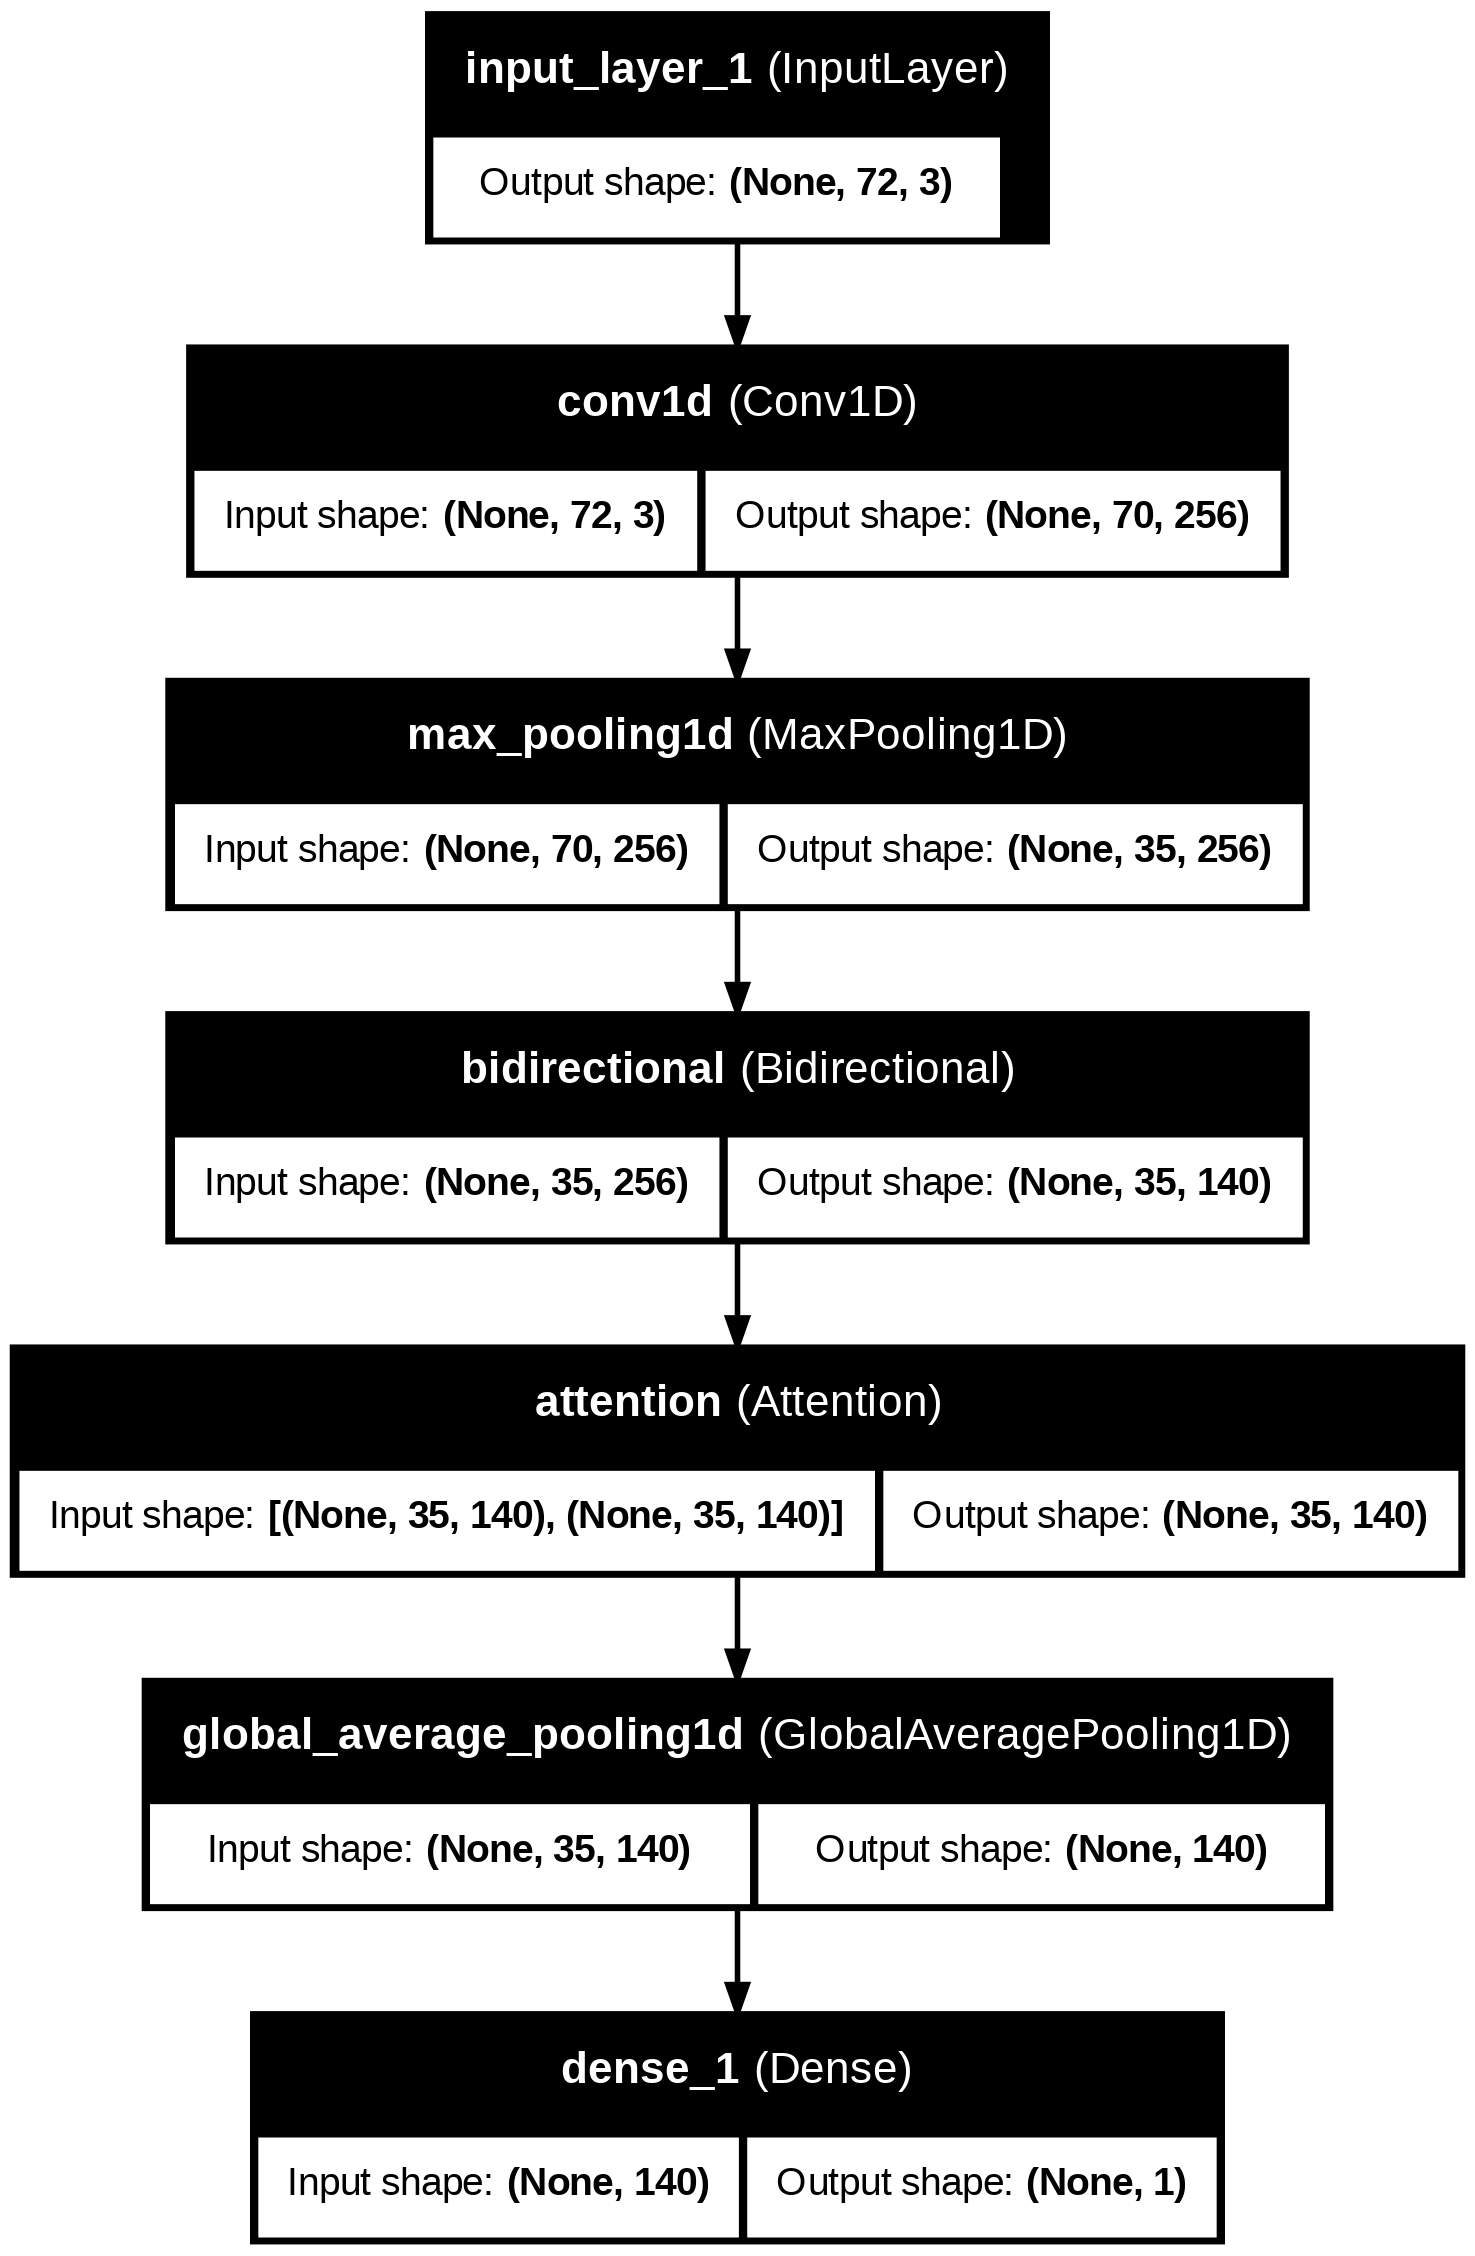

In [ ]:
# Visualizza l'architettura del modello e salvala in un file
print("\nSalvataggio del grafico del modello in 'model_plot.png'...")
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)
print("Grafico salvato!")
from IPython.display import Image

# ... dopo la riga plot_model ...
Image(filename='model_plot.png')

In [ ]:
import numpy as np

# 1. Rimodella test_X nel formato 3D richiesto dall'LSTM
#    (campioni, passi_temporali, feature)
test_X_reshaped = test_X.reshape((test_X.shape[0],72,3))
yhat = model.predict(test_X_reshaped)

N_FEATURES = 3

# Inverti le predizioni riportandole ai valori originali
inv_yhat_matrix = np.zeros((len(yhat), N_FEATURES))
inv_yhat_matrix[:, -1] = yhat.flatten()
inv_yhat = scaler.inverse_transform(inv_yhat_matrix)[:, -1]

# Inverti i valori reali per il confronto
inv_y_matrix = np.zeros((len(test_y), N_FEATURES))
inv_y_matrix[:, -1] = test_y.flatten()
inv_y = scaler.inverse_transform(inv_y_matrix)[:, -1]

# Ora inv_yhat e inv_y sono pronti per essere visualizzati
print("Primi 5 valori predetti in scala originale:", inv_yhat[:5])
print("Primi 5 valori reali in scala originale:", inv_y[:5])

273/273 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Primi 5 valori predetti in scala originale: [94.50731601 79.58523241 69.10825437 52.96767908 49.55560079]
Primi 5 valori reali in scala originale: [74.19 65.   40.   35.2  49.39]


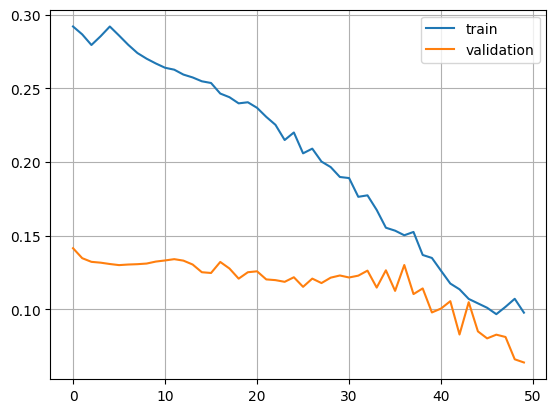

In [ ]:
# plot history
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='validation')
pyplot.legend()
pyplot.grid()
pyplot.show()

In [ ]:

from sklearn.metrics import mean_absolute_error
from statsmodels.tools.eval_measures import mse, rmse
import numpy as np
# Evaluation: forcasted values vs. real values
error1 = mse(inv_y, inv_yhat)
error2 = rmse(inv_y, inv_yhat)
error3 = mean_absolute_error(inv_y, inv_yhat)

# --- CORRECTED MAPE FUNCTION ---
def mean_absolute_percentage_error_safe(y_true, y_pred):
    # Convert inputs to numpy arrays
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    # Create a mask to select only the elements where the true value is NOT zero
    non_zero_mask = y_true != 0

    # Calculate MAPE only on these non-zero elements
    # This prevents division by zero and the resulting 'inf'
    mape = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

    return mape

# Calculate MAPE using the safe function
error4 = mean_absolute_percentage_error_safe(inv_y, inv_yhat)

print(f'MAE Error: {error3:11.10f}')
print(f'MSE Error : {error1:11.10f}')
print(f'RMSE Error: {error2:11.10f}')
print(f'MAPE Error: {error4:11.10f}')

MAE Error: 9.0520775708
MSE Error : 161.9042621899
RMSE Error: 12.7241605692
MAPE Error: 10.8968002993


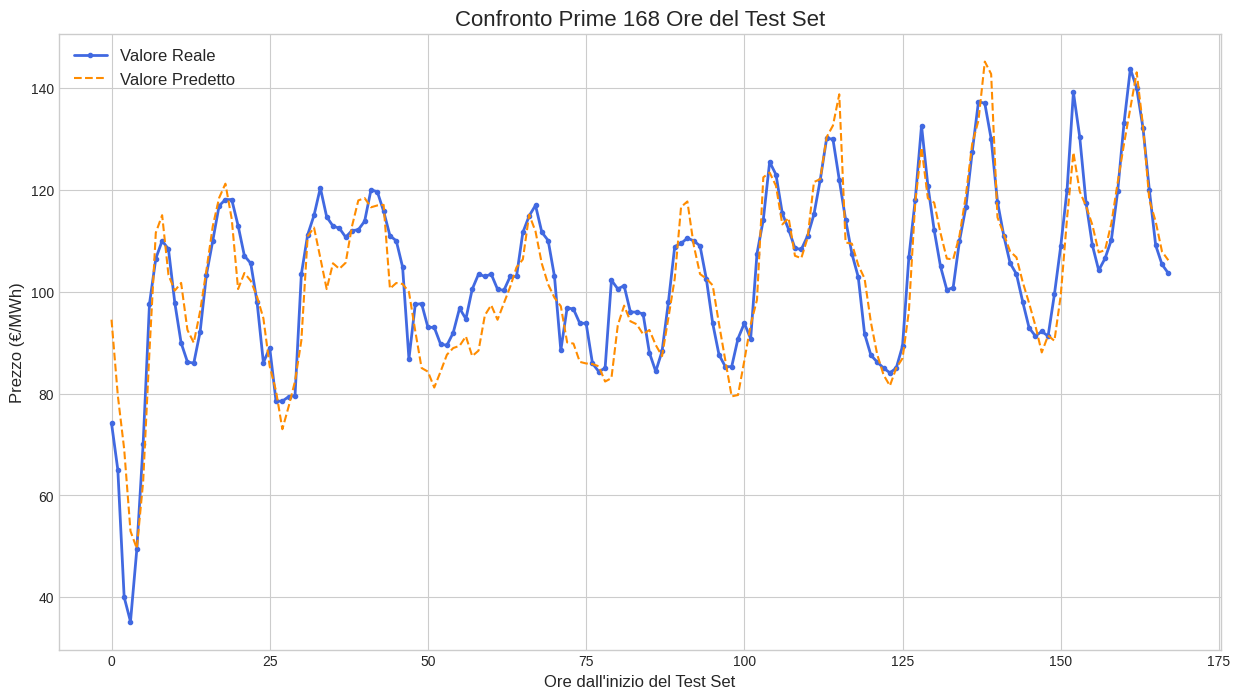

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Definisci il numero di ore da visualizzare (una settimana)
ore_da_plottare = 24 * 7

# 2. Seleziona i primi 168 valori dai tuoi risultati
reale_settimana = inv_y[:ore_da_plottare]
predetto_settimana = inv_yhat[:ore_da_plottare]

# 3. Crea il grafico
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(15, 8))

# L'asse X sarà semplicemente una sequenza di numeri da 0 a 167
asse_x = range(len(reale_settimana))

# Disegna i dati reali e predetti
ax.plot(asse_x, reale_settimana, label='Valore Reale', color='royalblue', linewidth=2, marker='o', markersize=3)
ax.plot(asse_x, predetto_settimana, label='Valore Predetto', color='darkorange', linestyle='--')

# Aggiungi titoli e etichette
ax.set_title('Confronto Prime 168 Ore del Test Set', fontsize=16)
ax.set_ylabel('Prezzo (€/MWh)', fontsize=12)
ax.set_xlabel("Ore dall'inizio del Test Set", fontsize=12)
ax.legend(fontsize=12)

# Mostra il grafico
plt.show()

PREVISIONE  24 ORE.



In [ ]:
DIVISIONE IN TRAIN E TEST

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split # Utile per la divisione

# Divisione tra train e test set

n_train_samples = 17520
train_values = values[:n_train_samples, :]
test_values = values[n_train_samples:, :] # Circa un anno

# scaler
scaler = RobustScaler()

# Applica .fit_transform() solo al set di training
scaled_train = scaler.fit_transform(train_values)

scaled_test = scaler.transform(test_values)


# 'scaled_train' e 'scaled_test' pronti per i passaggi successivi
print("Forma dei dati di training scalati:", scaled_train.shape)
print("Forma dei dati di test scalati:", scaled_test.shape)

Forma dei dati di training scalati: (17520, 3)
Forma dei dati di test scalati: (8784, 3)


PREPARAZIONE E SUDDIVISIONE IN SEQUENZE


In [ ]:

# Definisci i parametri della finestra temporale
N_IN = 168
N_OUT = 24
N_FEATURES = 3

# TRASFORMA IL SET DI TRAINING E TEST
reframed_train = series_to_supervised(scaled_train, n_in=N_IN, n_out=N_OUT)
reframed_test = series_to_supervised(scaled_test, n_in=N_IN, n_out=N_OUT)


# --- SOSTITUISCI IL VECCHIO CODICE CON QUESTO ---

# Divisione in INPUT (X) e OUTPUT (y)
train_values = reframed_train.values
test_values = reframed_test.values

# 1. Dividi correttamente X e y
n_input_cols = N_IN * N_FEATURES
train_X, train_y_full = train_values[:, :n_input_cols], train_values[:, n_input_cols:]
test_X, test_y_full = test_values[:, :n_input_cols], test_values[:, n_input_cols:]

# 2. Seleziona solo la colonna del prezzo per l'output
# Vogliamo predire la terza feature (indice 2, perché si parte da 0).
# Selezioniamo ogni terza colonna dall'output completo.
train_y = train_y_full[:, N_FEATURES-1::N_FEATURES]
test_y = test_y_full[:, N_FEATURES-1::N_FEATURES]


# --- Verifica finale. ORA LE FORME SARANNO CORRETTE ---
print("--- Set di Training ---")
print("Forma di train_X:", train_X.shape)
print("Forma di train_y:", train_y.shape)
print("\n--- Set di Test ---")
print("Forma di test_X:", test_X.shape)
print("Forma di test_y:", test_y.shape)

--- Set di Training ---
Forma di train_X: (17329, 504)
Forma di train_y: (17329, 24)

--- Set di Test ---
Forma di test_X: (8593, 504)
Forma di test_y: (8593, 24)


MODELLO CNN-BILSTM


In [ ]:
from keras.models import Sequential, Model
from keras.layers import LSTM, Dense, Input, Conv1D, MaxPooling1D, Bidirectional, MultiHeadAttention, GlobalAveragePooling1D

# --- 1. Parametri ---
N_IN = 168
N_OUT = 24
N_FEATURES = 3


print(f"Forma di train_X PRIMA del reshape: {train_X.shape}")
train_X = train_X.reshape((train_X.shape[0], N_IN, N_FEATURES))
test_X = test_X.reshape((test_X.shape[0], N_IN, N_FEATURES))
print(f"Forma di train_X DOPO il reshape: {train_X.shape}")
# Definisci il modello
model = Sequential()
model.add(Conv1D(filters=256, kernel_size=3, activation='relu', input_shape=(N_IN, N_FEATURES)))

# 2. STRATO DI MAXPOOLING - Invariato
# Riduce la lunghezza della sequenza, mantenendo le feature più rilevanti.
model.add(MaxPooling1D(pool_size=2))

# 3. STRATO LSTM BIDIREZIONALE  <-- MODIFICA APPLICATA QUI
# Lo strato LSTM originale è stato avvolto da 'Bidirectional'.
# Ora la rete processa i pattern estratti dal CNN in entrambe le direzioni temporali.
# Il numero di unità in output raddoppia è PARI A 140 .
model.add(Bidirectional(LSTM(70)))

# 4. STRATO DI OUTPUT

# Aggiungi gli altri strati ovvero  le 24 ore
model.add(Dense(N_OUT ))
model.compile(loss='mae', optimizer='adam')

# Stampa un riepilogo per verificare che la forma sia corretta
print("Riepilogo del Modello Aggiornato:")
model.summary()

# Ora l'addestramento funzionerà perché le dimensioni corrispondono
history = model.fit(
    train_X,
    train_y,
    epochs=30,
    batch_size=64,
    validation_data=(test_X, test_y),
    verbose=2,
    shuffle=False
)


Forma di train_X PRIMA del reshape: (17329, 504)
Forma di train_X DOPO il reshape: (17329, 168, 3)
Riepilogo del Modello Aggiornato:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 166, 256)       │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 83, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 140)            │       183,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │         3,384 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 189,064 (738.53 KB)

 Trainable params: 189,064 (738.53 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
271/271 - 7s - 26ms/step - loss: 0.3212 - val_loss: 0.1360
Epoch 2/30
271/271 - 7s - 27ms/step - loss: 0.2852 - val_loss: 0.1232
Epoch 3/30
271/271 - 8s - 29ms/step - loss: 0.2620 - val_loss: 0.1204
Epoch 4/30
271/271 - 5s - 20ms/step - loss: 0.2559 - val_loss: 0.1202
Epoch 5/30
271/271 - 11s - 40ms/step - loss: 0.2488 - val_loss: 0.1202
Epoch 6/30
271/271 - 4s - 14ms/step - loss: 0.2455 - val_loss: 0.1198
Epoch 7/30
271/271 - 4s - 14ms/step - loss: 0.2391 - val_loss: 0.1186
Epoch 8/30
271/271 - 4s - 15ms/step - loss: 0.2294 - val_loss: 0.1168
Epoch 9/30
271/271 - 4s - 14ms/step - loss: 0.2221 - val_loss: 0.1158
Epoch 10/30
271/271 - 4s - 14ms/step - loss: 0.2137 - val_loss: 0.1144
Epoch 11/30
271/271 - 4s - 15ms/step - loss: 0.2062 - val_loss: 0.1135
Epoch 12/30
271/271 - 6s - 24ms/step - loss: 0.1967 - val_loss: 0.1123
Epoch 13/30
271/271 - 4s - 15ms/step - loss: 0.1914 - val_loss: 0.1106
Epoch 14/30
271/271 - 4s - 14ms/step - loss: 0.1896 - val_loss: 0.1101
Epoch 15/30
27

MODELLO CNN-BILSTM CON ATTENTION


In [ ]:
from keras.models import Model
from keras.layers import Input, LSTM, Dense, Conv1D, MaxPooling1D, Bidirectional, Attention, GlobalAveragePooling1D

# --- 1. Parametri ---
N_IN = 168
N_FEATURES = 3
N_OUT = 24  # Previsione giornaliera (24 ore)

# Reshape dei dati
train_X = train_X.reshape((train_X.shape[0], N_IN, N_FEATURES))
test_X = test_X.reshape((test_X.shape[0], N_IN, N_FEATURES))

# --- Definizione Modello FUNZIONALE ---

# 1. STRATO DI INPUT
inputs = Input(shape=(N_IN, N_FEATURES))

# 2. STRATO CONVOLUZIONALE (Estrattore di pattern locali)
cnn_out = Conv1D(filters=256, kernel_size=3, activation='relu')(inputs)

# 3. STRATO DI MAXPOOLING (Riduzione dimensionalità temporale)
cnn_out = MaxPooling1D(pool_size=2)(cnn_out)

# 4. STRATO LSTM BIDIREZIONALE (Elaborazione del contesto temporale)
# Nota: return_sequences=True è NECESSARIO per passare la sequenza all'Attention
lstm_out = Bidirectional(LSTM(70, return_sequences=True))(cnn_out)

# 5. MECCANISMO DI ATTENZIONE (Self-Attention)
# Il modello confronta ogni istante della sequenza BiLSTM con tutti gli altri
attn_out = Attention()([lstm_out, lstm_out])

# 6. GLOBAL AVERAGE POOLING (Sintesi informativa)
# Trasforma la matrice pesata (35, 140) in un unico vettore di 140 componenti
gap_out = GlobalAveragePooling1D()(attn_out)

# 7. STRATO DI OUTPUT (Combinazione lineare finale)
outputs = Dense(N_OUT)(gap_out)

# --- Fine Definizione Modello ---

# Creazione e Compilazione
model = Model(inputs=inputs, outputs=outputs)
model.compile(loss='mae', optimizer='adam')

# Riepilogo
print("Riepilogo del Modello CNN-BiLSTM-ATTENTION (Attention alla fine):")
model.summary()

# Addestramento
history = model.fit(
    train_X,
    train_y,
    epochs=50,
    batch_size=64,
    validation_data=(test_X, test_y),
    verbose=2,
    shuffle=False
)

Riepilogo del Modello CNN-BiLSTM-ATTENTION (Attention alla fine):


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 168, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 166, 256)  │      2,560 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 83, 256)   │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 83, 140)   │    183,120 │ max_pooling1d[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 83, 140)   │          0 │ bidirectional[0]… │
│ (Attention)         │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 140)       │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 24)        │      3,384 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 189,064 (738.53 KB)

 Trainable params: 189,064 (738.53 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
271/271 - 9s - 32ms/step - loss: 0.3472 - val_loss: 0.1583
Epoch 2/50
271/271 - 4s - 16ms/step - loss: 0.3483 - val_loss: 0.1554
Epoch 3/50
271/271 - 4s - 15ms/step - loss: 0.3580 - val_loss: 0.1623
Epoch 4/50
271/271 - 4s - 15ms/step - loss: 0.3387 - val_loss: 0.1555
Epoch 5/50
271/271 - 4s - 16ms/step - loss: 0.3224 - val_loss: 0.1644
Epoch 6/50
271/271 - 4s - 15ms/step - loss: 0.3026 - val_loss: 0.1695
Epoch 7/50
271/271 - 4s - 15ms/step - loss: 0.2829 - val_loss: 0.1642
Epoch 8/50
271/271 - 4s - 16ms/step - loss: 0.2750 - val_loss: 0.1540
Epoch 9/50
271/271 - 4s - 15ms/step - loss: 0.2720 - val_loss: 0.1490
Epoch 10/50
271/271 - 4s - 16ms/step - loss: 0.2686 - val_loss: 0.1502
Epoch 11/50
271/271 - 4s - 15ms/step - loss: 0.2676 - val_loss: 0.1510
Epoch 12/50
271/271 - 4s - 15ms/step - loss: 0.2659 - val_loss: 0.1471
Epoch 13/50
271/271 - 4s - 16ms/step - loss: 0.2614 - val_loss: 0.1499
Epoch 14/50
271/271 - 4s - 15ms/step - loss: 0.2596 - val_loss: 0.1537
Epoch 15/50
271

In [ ]:
from keras.models import Model
from keras.layers import Input, LSTM, Dense, Conv1D, MaxPooling1D, Bidirectional, Attention

# --- 1. Parametri ---
N_IN = 168
N_FEATURES = 3
N_OUT = 24  # Un singolo output per la previsione

# Ensure X data is reshaped to 3D for the model
# print(f"Forma di train_X PRIMA del reshape: {train_X.shape}") # This line can be commented or removed
train_X = train_X.reshape((train_X.shape[0], N_IN, N_FEATURES))
test_X = test_X.reshape((test_X.shape[0], N_IN, N_FEATURES))
# print(f"Forma di train_X DOPO il reshape: {train_X.shape}") # This line can be commented or removed

#  Definizione Modello FUNZIONALE

# 1. STRATO DI INPUT
inputs = Input(shape=(N_IN, N_FEATURES))

# 2. STRATO CONVOLUZIONALE (Conv1D)
# Output shape: [batch, 166, 256] (supponendo padding 'valid')
cnn_out = Conv1D(filters=256, kernel_size=3, activation='relu')(inputs)

# 3. STRATO DI MAXPOOLING
# Output shape: [batch, 83, 256]
cnn_out = MaxPooling1D(pool_size=2)(cnn_out)

# 4. MECCANISMO DI ATTENZIONE (Self-Attention)
# Applichiamo l'attenzione sull'output della CNN.
# "Pesa" i pattern estratti dalla CNN prima di darli all'LSTM.
# L'output ha ancora forma: [batch, 83, 256]
attn_out = Attention()([cnn_out, cnn_out])

# 5. STRATO LSTM BIDIREZIONALE
# ---> MODIFICA CHIAVE: return_sequences=False (default)
# L'LSTM riceve la sequenza "pesata" dall'attenzione (attn_out)
# e la collassa in un singolo vettore di stato finale.
# L'output ha forma: [batch, 140] (70 forward + 70 backward)
lstm_out = Bidirectional(LSTM(70))(attn_out)

# 6. STRATO DI OUTPUT
# Il vettore finale (lstm_out) viene usato per la previsione.
# L'output ha forma: [batch, 1]
outputs = Dense(N_OUT)(lstm_out)

# 7. CREAZIONE DEL MODELLO FINALE
model = Model(inputs=inputs, outputs=outputs)

# --- Fine Definizione Modello ---

# Compilazione
model.compile(loss='mae', optimizer='adam')

# Stampa un riepilogo del nuovo modello
print("Riepilogo del Modello CNN-ATTENTION-BiLSTM:")
model.summary()

# Addestramento
history = model.fit(
    train_X,
    train_y,
    epochs=50,
    batch_size=64,
    validation_data=(test_X, test_y), # Questi dovrebbero essere i tuoi dati di VALIDAZIONE
    verbose=2,
    shuffle=False
)

Riepilogo del Modello CNN-ATTENTION-BiLSTM:


Model: "functional_34"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 168, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 166, 256)  │      2,560 │ input_layer_14[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_6     │ (None, 83, 256)   │          0 │ conv1d_6[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_1         │ (None, 83, 256)   │          0 │ max_pooling1d_6[… │
│ (Attention)         │                   │            │ max_pooling1d_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_8     │ (None, 140)       │    183,120 │ attention_1[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 24)        │      3,384 │ bidirectional_8[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 189,064 (738.53 KB)

 Trainable params: 189,064 (738.53 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
271/271 - 7s - 26ms/step - loss: 0.3401 - val_loss: 0.1528
Epoch 2/50
271/271 - 4s - 14ms/step - loss: 0.3474 - val_loss: 0.1518
Epoch 3/50
271/271 - 4s - 16ms/step - loss: 0.3465 - val_loss: 0.1536
Epoch 4/50
271/271 - 4s - 14ms/step - loss: 0.3326 - val_loss: 0.1603
Epoch 5/50
271/271 - 4s - 15ms/step - loss: 0.3194 - val_loss: 0.1678
Epoch 6/50
271/271 - 4s - 16ms/step - loss: 0.3053 - val_loss: 0.1704
Epoch 7/50
271/271 - 4s - 14ms/step - loss: 0.2918 - val_loss: 0.1735
Epoch 8/50
271/271 - 4s - 14ms/step - loss: 0.2800 - val_loss: 0.1646
Epoch 9/50
271/271 - 4s - 16ms/step - loss: 0.2687 - val_loss: 0.1606
Epoch 10/50
271/271 - 4s - 15ms/step - loss: 0.2618 - val_loss: 0.1575
Epoch 11/50
271/271 - 4s - 15ms/step - loss: 0.2562 - val_loss: 0.1564
Epoch 12/50
271/271 - 4s - 16ms/step - loss: 0.2519 - val_loss: 0.1534
Epoch 13/50
271/271 - 4s - 15ms/step - loss: 0.2495 - val_loss: 0.1535
Epoch 14/50
271/271 - 4s - 15ms/step - loss: 0.2451 - val_loss: 0.1566
Epoch 15/50
271

In [ ]:
import numpy as np

# --- 1. Get Predictions (this part is correct) ---
# Reshape test_X to the 3D format the model expects
test_X_reshaped = test_X.reshape((test_X.shape[0],168, 3))
yhat = model.predict(test_X_reshaped)
# The shape of yhat is now (number_of_samples, 24)

# --- 2. Inverse Transform Predictions (Corrected Logic) ---
# Create a placeholder matrix that can hold all predicted values
# We have yhat.shape[0] samples and yhat.shape[1] (24) timesteps
# Total values = yhat.shape[0] * yhat.shape[1]
inv_yhat_matrix = np.zeros((yhat.shape[0] * yhat.shape[1], N_FEATURES))

# Put all 24*N predictions into the last column of the placeholder
inv_yhat_matrix[:, -1] = yhat.flatten()

# Apply the inverse scaler
inv_yhat_full = scaler.inverse_transform(inv_yhat_matrix)

# Extract only the column with our predictions and reshape it back to (samples, 24)
inv_yhat = inv_yhat_full[:, -1].reshape(yhat.shape)


# --- 3. Inverse Transform Actual Values (Corrected Logic) ---
# Do the exact same process for the true values (test_y)
inv_y_matrix = np.zeros((test_y.shape[0] * test_y.shape[1], N_FEATURES))
inv_y_matrix[:, -1] = test_y.flatten()
inv_y_full = scaler.inverse_transform(inv_y_matrix)
inv_y = inv_y_full[:, -1].reshape(test_y.shape)


# --- 4. Print Results ---
# Now inv_yhat and inv_y are both in shape (samples, 24)
print("Shape of final predictions:", inv_yhat.shape)
print("Shape of final actuals:", inv_y.shape)
print("\nPredicted values for the first sample (24 hours):", inv_yhat[0])
print("\nReal values for the first sample (24 hours):", inv_y[0])

269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Shape of final predictions: (8593, 24)
Shape of final actuals: (8593, 24)

Predicted values for the first sample (24 hours): [ 94.01756566  89.47792513  89.97529928  89.33517921  88.93511996
  87.92571378  89.86024328  92.54988146  92.20837794  96.17465918
  95.70430104  91.76467357  88.6678915   91.27821702  95.42379624
  99.24151894 107.04327239 116.55867614 121.1302102  122.31987471
 115.91868243 109.01724762 104.17990034 101.12752577]

Real values for the first sample (24 hours): [ 87.6   85.28  85.28  90.79  93.8   90.79 107.46 114.18 125.5  123.
 115.38 112.22 108.55 108.3  110.97 115.2  122.   130.1  129.99 122.01
 114.18 107.46 102.9   91.75]


MAPE Error: 34.4089965626
--- Metriche di Valutazione del Modello ---
 RMSE: 21.2304
 MAE:  15.2774
MAPE Error: 34.4089965626


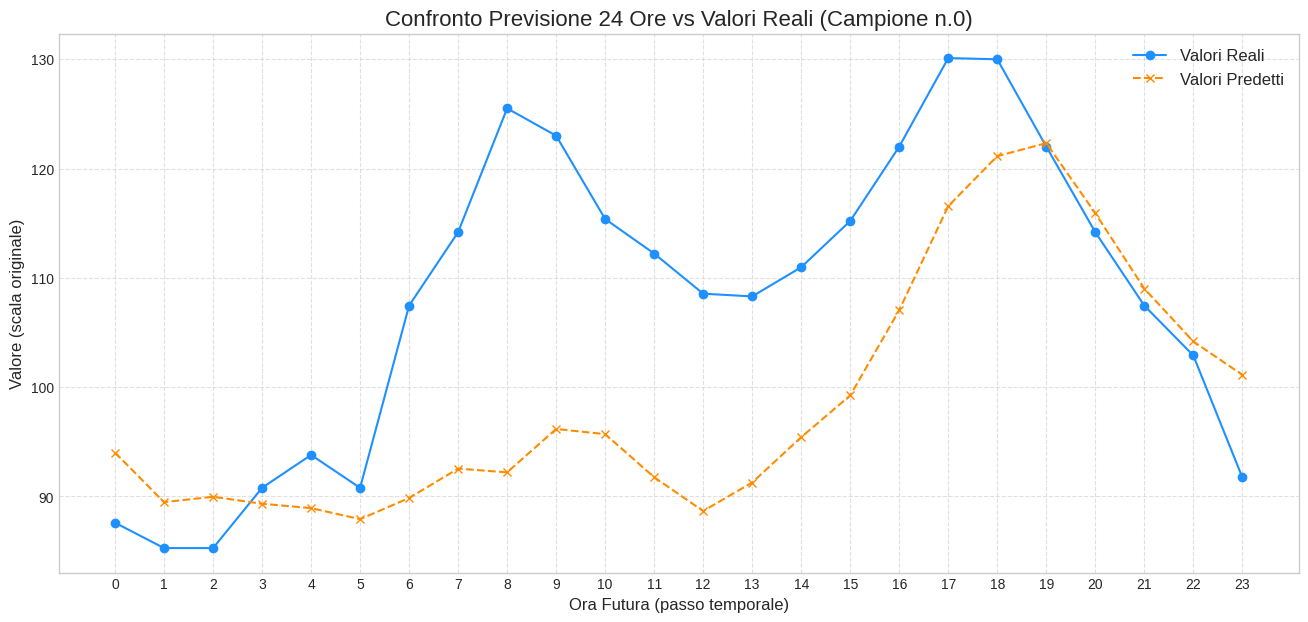

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error



# --- 1. Calcolo delle Metriche di Errore ---
# Le metriche vengono calcolate su tutte le previsioni del test set.

# RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(inv_y, inv_yhat))

# MAE (Mean Absolute Error)
mae = mean_absolute_error(inv_y, inv_yhat)

# --- CORRECTED MAPE FUNCTION ---
def mean_absolute_percentage_error_safe(y_true, y_pred):
    # Convert inputs to numpy arrays
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    # Create a mask to select only the elements where the true value is NOT zero
    non_zero_mask = y_true != 0

    # Calculate MAPE only on these non-zero elements
    # This prevents division by zero and the resulting 'inf'
    mape = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

    return mape


# Calculate MAPE using the safe function
error4 = mean_absolute_percentage_error_safe(inv_y, inv_yhat)


print(f'MAPE Error: {error4:11.10f}')



print("--- Metriche di Valutazione del Modello ---")
print(f" RMSE: {rmse:.4f}")
print(f" MAE:  {mae:.4f}")
print(f'MAPE Error: {error4:11.10f}')


# --- 2. Creazione del Grafico di Confronto
# Scegliamo un campione dal test set da visualizzare (es. il primo)
sample_index = 0
true_values_sample = inv_y[sample_index]
predicted_values_sample = inv_yhat[sample_index]

# Creiamo il grafico
plt.figure(figsize=(16, 7))
plt.plot(true_values_sample, label='Valori Reali', color='dodgerblue', marker='o', linestyle='-')
plt.plot(predicted_values_sample, label='Valori Predetti', color='darkorange', marker='x', linestyle='--')

# Aggiungiamo titoli e legende per chiarezza
plt.title(f'Confronto Previsione 24 Ore vs Valori Reali (Campione n.{sample_index})', fontsize=16)
plt.xlabel('Ora Futura (passo temporale)', fontsize=12)
plt.ylabel('Valore (scala originale)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(np.arange(0, 24, 1)) # Mostra tutte le 24 ore sull'asse X

# Mostra il grafico
plt.show()

ANALISI SULLA VOLATILITÀ DI GENNAIO E LUGLIO



In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import gaussian_kde
import plotly.graph_objects as go

# Assicurati di aver installato le librerie:
# pip install pandas numpy scipy plotly openpyxl

def plot_seasonal_density_surface(file_path, month, month_name):
    """
    Crea una superficie di densità 3D per un mese specifico, per il confronto stagionale.
    """
    try:
        # 1. CARICA E PREPARA I DATI (come prima)
        data = pd.read_csv(file_path, decimal=',') # <-- USA LA VARIABILE file_path
        data.rename(columns={'€/MWh': 'Price'}, inplace=True)
        data['Date_Only'] = pd.to_datetime(data['Data'], format='%d/%m/%Y')
        data['Hour'] = data.groupby('Date_Only').cumcount()
        data['DateTime'] = data['Date_Only'] + pd.to_timedelta(data['Hour'], unit='h')
        data.set_index('DateTime', inplace=True)
        data = data[['Price']].copy()
        data.rename(columns={'Price': 'Close'}, inplace=True)
    except Exception as e:
        print(f"Errore durante la lettura del file: {e}")
        return

    # 2. FILTRA I DATI PER IL MESE SPECIFICATO
    seasonal_data = data[data.index.month == month].copy()
    if seasonal_data.empty:
        print(f"Attenzione: Nessun dato trovato per il mese di {month_name}. Salto il grafico.")
        return

    # 3. Calcolo della fluttuazione (ora su dati stagionali)
    daily_means = seasonal_data['Close'].groupby(seasonal_data.index.date).transform('mean')
    close_prices_np = seasonal_data['Close'].values
    daily_means_np = daily_means.values
    fluctuation_np = ((close_prices_np - daily_means_np) / daily_means_np) * 100
    seasonal_data['Fluctuation'] = fluctuation_np
    seasonal_data.dropna(inplace=True)

    if len(seasonal_data) < 10:
        print(f"Dati insufficienti per {month_name} dopo la preparazione.")
        return

    # 4. PREPARA I DATI PER IL GRAFICO (AGGREGAZIONE STAGIONALE) <--- MODIFICA QUI

    # Aggiungi colonne per Anno e Giorno del Mese
    seasonal_data['Year'] = seasonal_data.index.year
    seasonal_data['DayOfMonth'] = seasonal_data.index.day # Valori da 1 a 31

    # Trova gli anni unici, in ordine
    unique_years = sorted(seasonal_data['Year'].unique())

    # Calcola i giorni nel mese (es. 31 per Gennaio/Luglio)
    days_in_month = pd.Period(f'2001-{month}-01').days_in_month

    # Crea una mappa per l'offset (es. 0 per il primo anno, 31 per il secondo, 62 per il terzo)
    offset_map = {year: i * days_in_month for i, year in enumerate(unique_years)}

    # Applica l'offset. Sottraiamo 1 da DayOfMonth per partire da 0 (giorni 0-30)
    # Esempio per Gennaio (31 giorni) con 3 anni:
    # Anno 1: (Giorno 1-31) - 1 + 0   = Asse X da 0 a 30
    # Anno 2: (Giorno 1-31) - 1 + 31  = Asse X da 31 a 61
    # Anno 3: (Giorno 1-31) - 1 + 62  = Asse X da 62 a 92
    seasonal_data['Aggregated_Day'] = (seasonal_data['DayOfMonth'] - 1) + seasonal_data['Year'].map(offset_map)

    # Usa le nuove colonne per x e y
    x = seasonal_data['Aggregated_Day'].values
    y = seasonal_data['Fluctuation'].values

    if len(x) == 0:
        print(f"Errore: 'x' è vuoto dopo l'aggregazione per {month_name}.")
        return

    k = gaussian_kde(np.vstack([x, y]))
    xi, yi = np.mgrid[x.min():x.max():complex(0, 100), y.min():y.max():complex(0, 100)]
    zi = k(np.vstack([xi.flatten(), yi.flatten()]))

    # 6. Creazione del grafico 3D con Plotly (Titolo asse X aggiornato) <--- MODIFICA QUI
    fig = go.Figure(data=[go.Surface(z=zi.reshape(xi.shape), x=xi, y=yi, colorscale='Plasma')])

    # Aggiorna il titolo dell'asse X
    fig.update_layout(title=f'Analisi Volatilità 3D - Prezzi Energia - {month_name}',
                      scene=dict(xaxis_title=f'Giorno Aggregato ({month_name})', # <-- TITOLO ASSE X CORRETTO
                                 yaxis_title='Fluttuazione dalla Media Giornaliera (%)',
                                 zaxis_title='Probabilità'),
                      autosize=True, height=700)
    fig.show()
file_dei_tuoi_dati = "../data/dataset_finale_4_anni.csv"

# Crea il grafico per l'inverno
print("--- Creazione grafico per l'Inverno (Gennaio) ---")
plot_seasonal_density_surface(file_dei_tuoi_dati, 1, "Inverno (Gennaio)")

# Crea il grafico per l'estate ☀
print("\n--- Creazione grafico per l'Estate (Luglio) ---")
plot_seasonal_density_surface(file_dei_tuoi_dati, 7, "Estate (Luglio)")

--- Creazione grafico per l'Inverno (Gennaio) ---



--- Creazione grafico per l'Estate (Luglio) ---


In [ ]:
!pip install -U kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 4.9 MB/s eta 0:00:00


In [ ]:


import pandas as pd
import numpy as np
import plotly.graph_objects as go
import os

def plot_seasonal_density_histogram(file_path, month, month_name, output_dir="grafici_tesi_HISTOGRAM"):
    print(f"\n--- Elaborazione: {month_name} ---")

    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    try:
        data = pd.read_csv(file_path, decimal=',')
        data.rename(columns={'€/MWh': 'Price'}, inplace=True)
        data['Date_Only'] = pd.to_datetime(data['Data'], format='%d/%m/%Y', dayfirst=True)
        data['Hour'] = data.groupby('Date_Only').cumcount()
        data['DateTime'] = data['Date_Only'] + pd.to_timedelta(data['Hour'], unit='h')
        data.set_index('DateTime', inplace=True)
        data = data[['Price']].copy()
        data.rename(columns={'Price': 'Close'}, inplace=True)
    except Exception as e:
        print(f"Errore durante la lettura del file: {e}")
        return

    seasonal_data = data[data.index.month == month].copy()

    if seasonal_data.empty:
        print(f"Attenzione: Nessun dato trovato per {month_name}.")
        return

    # CALCOLO FLUTTUAZIONE %
    daily_means = seasonal_data['Close'].groupby(seasonal_data.index.date).transform('mean')
    close_prices_np = seasonal_data['Close'].values
    daily_means_np = daily_means.values
    daily_means_np[daily_means_np == 0] = np.nan

    fluctuation_np = ((close_prices_np - daily_means_np) / daily_means_np) * 100
    seasonal_data['Fluctuation'] = fluctuation_np
    seasonal_data.replace([np.inf, -np.inf], np.nan, inplace=True)
    seasonal_data.dropna(inplace=True)

    # --- TABELLA BIN 4% ---
    bin_edges = np.linspace(-60, 60, 31)
    labels = [f"[{bin_edges[i]:.0f}%, {bin_edges[i+1]:.0f}%)" for i in range(len(bin_edges)-1)]
    seasonal_data['Bin'] = pd.cut(seasonal_data['Fluctuation'], bins=bin_edges, labels=labels, right=False)

    bin_table = seasonal_data['Bin'].value_counts().reindex(labels).reset_index()
    bin_table.columns = ['Intervallo (Step 4%)', 'Conteggio (Ore)']
    bin_table['Percentuale (%)'] = (bin_table['Conteggio (Ore)'] / bin_table['Conteggio (Ore)'].sum() * 100).round(2)

    print(bin_table.to_string(index=False))
    bin_table.to_csv(os.path.join(output_dir, f"tabella_bin_{month_name}.csv"), index=False)

    # --- AGGREGAZIONE TEMPORALE ---
    seasonal_data['Year'] = seasonal_data.index.year
    seasonal_data['DayOfMonth'] = seasonal_data.index.day
    unique_years = sorted(seasonal_data['Year'].unique())
    days_in_month = 31
    offset_map = {year: i * days_in_month for i, year in enumerate(unique_years)}
    seasonal_data['Aggregated_Day'] = (seasonal_data['DayOfMonth'] - 1) + seasonal_data['Year'].map(offset_map)

    x = seasonal_data['Aggregated_Day'].values
    y = seasonal_data['Fluctuation'].values

    # --- GRAFICO CON Z-RANGE FISSO A 35 ---
    fig = go.Figure(data=[
        go.Histogram2dContour(
            x = x,
            y = y,
            colorscale = 'Plasma',
            zmin = 0,
            zmax = 35,  # FISSO PER CONFRONTO
            colorbar=dict(title='Frequenza (Ore)'),
            contours=dict(
                coloring='fill',
                showlabels = True,
                labelfont = dict(size = 10, color = 'white')
            ),
            nbinsx=40,
            nbinsy=30
        )
    ])

    fig.update_layout(
        title=f'Mappa Densità {month_name} (Z-Max Fisso: 35)',
        xaxis_title='Progressione Temporale (Giorni)',
        yaxis_title='Fluttuazione (%)',
        yaxis=dict(range=[-60, 60]),
        height=600, width=950,
        plot_bgcolor='white'
    )

    # --- SALVATAGGIO ROBUSTO ---
    try:
        img_filename = f"density_map_Z35_{month_name}.png"
        fig.write_image(os.path.join(output_dir, img_filename), engine="kaleido", scale=2)
        print(f"Immagine salvata correttamente: {img_filename}")
    except Exception as e:
        print(f"Salvataggio immagine fallito (ma il grafico apparirà qui sotto). Errore: {e}")
        print("Tip: Esegui '!pip install -U kaleido' per abilitare il salvataggio.")

    fig.show()

# --- ESECUZIONE ---
path_dataset = "../data/dataset_finale_4_anni.csv"
cartella_output = "confronto_Z_fisso"

plot_seasonal_density_histogram(path_dataset, 1, "Gennaio", cartella_output)
plot_seasonal_density_histogram(path_dataset, 7, "Luglio", cartella_output)


--- Elaborazione: Gennaio ---
Intervallo (Step 4%)  Conteggio (Ore)  Percentuale (%)
        [-60%, -56%)                8             0.36
        [-56%, -52%)                3             0.14
        [-52%, -48%)                1             0.05
        [-48%, -44%)                8             0.36
        [-44%, -40%)                9             0.41
        [-40%, -36%)                7             0.32
        [-36%, -32%)               13             0.59
        [-32%, -28%)               21             0.95
        [-28%, -24%)               38             1.72
        [-24%, -20%)               56             2.54
        [-20%, -16%)              130             5.89
        [-16%, -12%)              186             8.42
         [-12%, -8%)              163             7.38
          [-8%, -4%)              194             8.78
           [-4%, 0%)              271            12.27
            [0%, 4%)              244            11.05
            [4%, 8%)              


--- Elaborazione: Luglio ---
Intervallo (Step 4%)  Conteggio (Ore)  Percentuale (%)
        [-60%, -56%)                0             0.00
        [-56%, -52%)                3             0.14
        [-52%, -48%)                5             0.23
        [-48%, -44%)                3             0.14
        [-44%, -40%)                5             0.23
        [-40%, -36%)                5             0.23
        [-36%, -32%)                8             0.36
        [-32%, -28%)               10             0.46
        [-28%, -24%)               16             0.73
        [-24%, -20%)               84             3.83
        [-20%, -16%)              174             7.93
        [-16%, -12%)              262            11.94
         [-12%, -8%)              265            12.08
          [-8%, -4%)              280            12.76
           [-4%, 0%)              268            12.22
            [0%, 4%)              207             9.43
            [4%, 8%)              1